## Algoritmo Genetico TSP




### TSP Inventado

In [31]:
from IPython.display import HTML
from alg_genetico_ import algoritmoGenetico, Punto
from lector_tsp import leer_tsp

file_path = "../data/custom_inventado.tsp"


puntos = leer_tsp(file_path)

# Ejecutar algoritmo genético
mejor_camino, animacion = algoritmoGenetico(
    ciudades=puntos,
    N=190,            # tamaño población
    maxIter=150,     # número de generaciones
    fracElite=0.1,   # 20% elite
    fracCrossover=0.7, # 60% cruce
    fracMutation=0.2   # 20% mutación
)


print("Mejor camino encontrado:")
for p in mejor_camino:
    print(p, end=" -> ")
print(mejor_camino[0])

# Mostrar animación en Jupyter Notebook
HTML(animacion.to_jshtml())


Distancia inicial: 3177.36
Generación 10: distancia = 1916.37
Generación 20: distancia = 1537.22
Generación 30: distancia = 1332.53
Generación 40: distancia = 1025.51
Generación 50: distancia = 987.68
Generación 60: distancia = 905.79
Generación 70: distancia = 841.71
Generación 80: distancia = 826.55
Generación 90: distancia = 802.47
Generación 100: distancia = 789.56
Generación 110: distancia = 774.49
Generación 120: distancia = 767.23
Generación 130: distancia = 764.85
Generación 140: distancia = 759.08
Generación 150: distancia = 759.08
Mejor camino encontrado:
(59) -> (43) -> (42) -> (52) -> (70) -> (65) -> (46) -> (77) -> (48) -> (58) -> (60) -> (76) -> (47) -> (57) -> (80) -> (67) -> (45) -> (66) -> (73) -> (79) -> (69) -> (78) -> (55) -> (50) -> (41) -> (56) -> (15) -> (16) -> (18) -> (30) -> (1) -> (10) -> (6) -> (33) -> (36) -> (12) -> (31) -> (11) -> (35) -> (3) -> (5) -> (13) -> (4) -> (14) -> (29) -> (7) -> (17) -> (8) -> (21) -> (24) -> (2) -> (32) -> (26) -> (22) -> (37)

## Algoritmos LP

In [2]:
from pathlib import Path
from tsplib import load_tsplib_2d
from tsp_utils import make_invented_instance, save_tsplib
from lp_tsp import solve_tsp_mtz, solve_tsp_cutplane
from main import distance_matrix, plot_tsp_route


### LP eil101

[eil101] Status=Optimal, Distancia=693.56, Tiempo=96.92s
✓ Guardado: plots/eil101_route.png


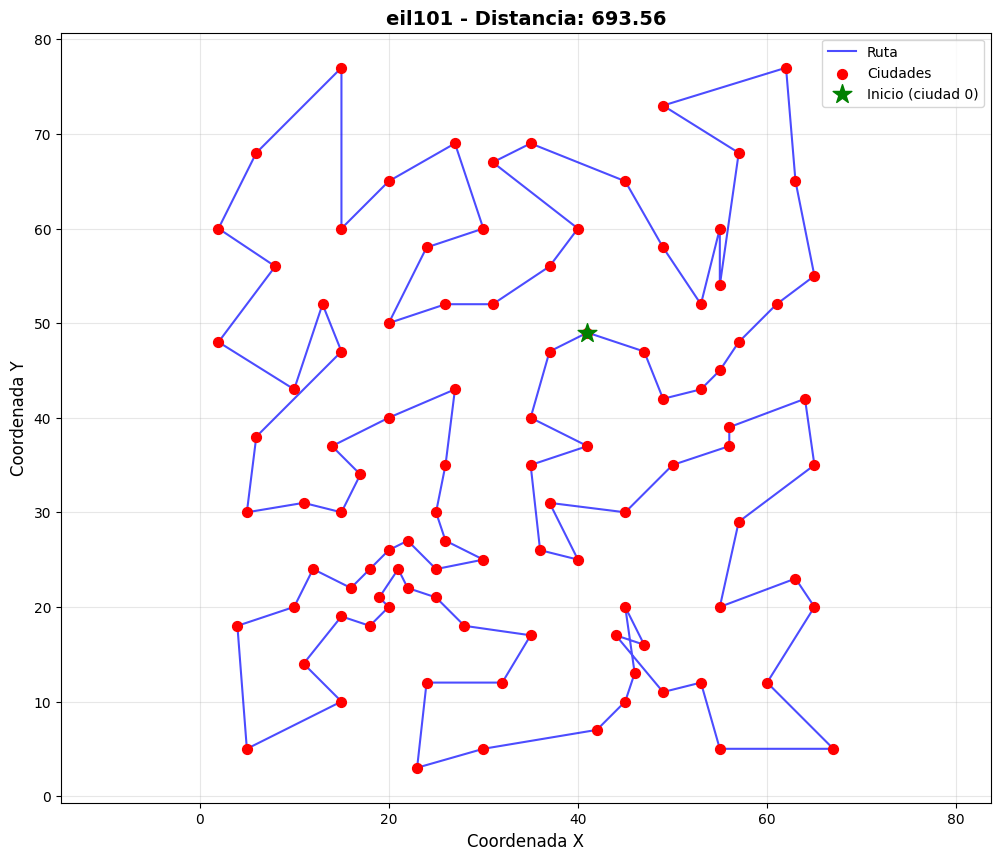

In [25]:


# Reemplaza argparse con simples variables
eil_path = "../data/eil101.tsp"
inventado_n = 80

eil = load_tsplib_2d(eil_path)
D = distance_matrix(eil.coords)
lp_res = solve_tsp_mtz(D, time_limit=100)  # Limita tiempo a 60s

print(f"[eil101] Status={lp_res.status}, Distancia={lp_res.length:.2f}, Tiempo={lp_res.elapsed:.2f}s")

plot_tsp_route(eil.coords, lp_res.route,
               title=f"eil101 - Distancia: {lp_res.length:.2f}",
               filename="plots/eil101_route.png")


### LP gr229

Iteración 1: 106 subtours encontrados
Iteración 2: 43 subtours encontrados
Iteración 3: 26 subtours encontrados
Iteración 4: 7 subtours encontrados
Iteración 5: 20 subtours encontrados
Iteración 6: 9 subtours encontrados
Iteración 7: 8 subtours encontrados
Iteración 8: 3 subtours encontrados
Iteración 9: 6 subtours encontrados
[gr229] Status=Optimal, Distancia=1635.31, Tiempo=179.62s
✓ Guardado: plots/gr229.png


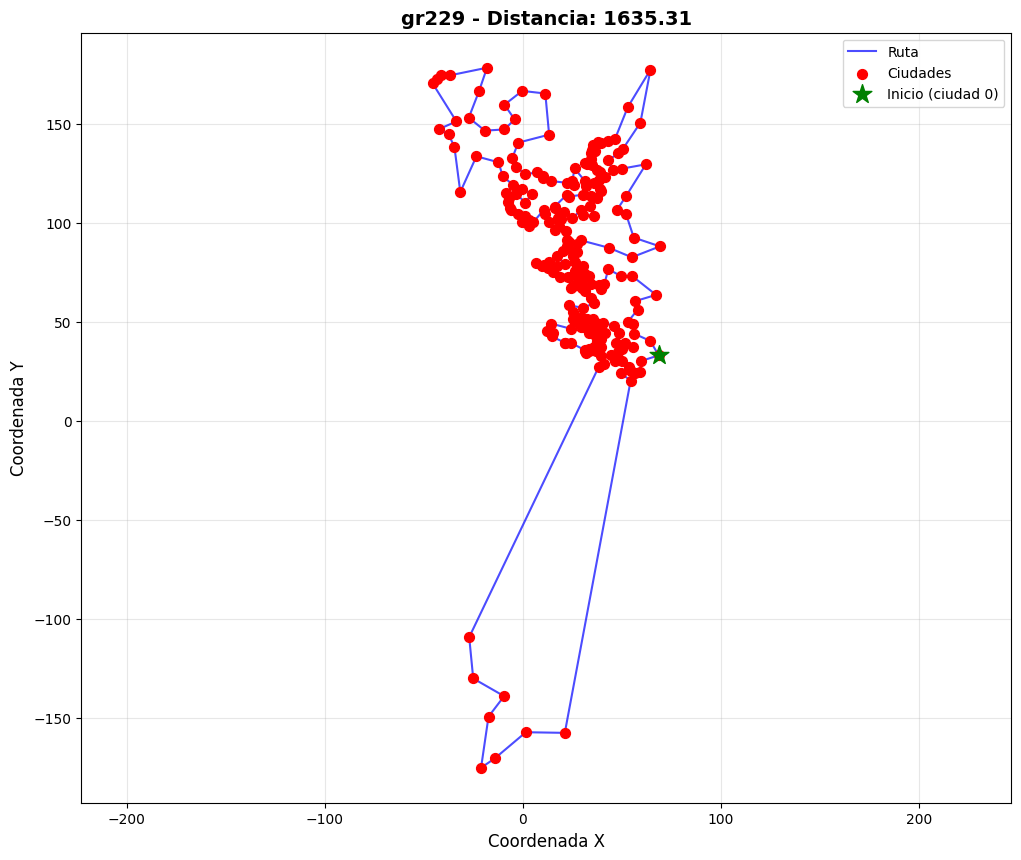

In [6]:
gr229_path = "../data/gr229.tsp"
gr229 = load_tsplib_2d(gr229_path)
D = distance_matrix(gr229.coords)
lp_res = solve_tsp_cutplane(D, 400)
print(f"[gr229] Status={lp_res.status}, Distancia={lp_res.length:.2f}, Tiempo={lp_res.elapsed:.2f}s")

plot_tsp_route(gr229.coords, lp_res.route,
               title=f"gr229 - Distancia: {lp_res.length:.2f}",
               filename="plots/gr229.png")


## LP Inventado

[custom] Status=Optimal, Distancia=563.02, Tiempo=96.89s
✓ Guardado: plots/custom_route.png


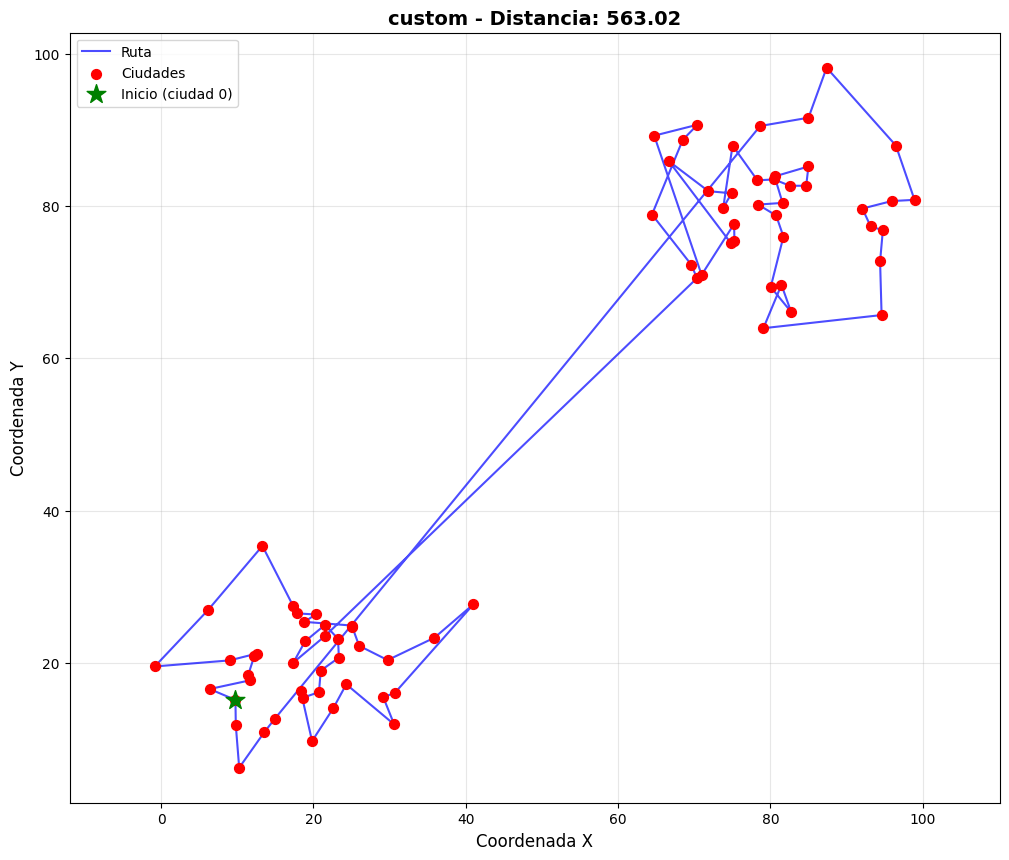

In [28]:
custom_path = "../data/custom_inventado.tsp"
custom = load_tsplib_2d(custom_path)
D = distance_matrix(custom.coords)
lp_res = solve_tsp_mtz(D, 100)
print(f"[custom] Status={lp_res.status}, Distancia={lp_res.length:.2f}, Tiempo={lp_res.elapsed:.2f}s")

plot_tsp_route(custom.coords, lp_res.route,
               title=f"custom - Distancia: {lp_res.length:.2f}",
               filename="plots/custom_route.png")
